# B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\0a38b552372d_0.png

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def procesare_ben_graham_detaliata(image_path, size=512):
    # 1. Incarcare si Resize
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Nu s-a gasit imaginea la calea: {image_path}")
    
    img_resized = cv2.resize(img, (size, size))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) 
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # =========================================================
    # PASUL 1: Extragerea și Eroziunea Măștii
    # =========================================================
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)
    
    contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_resized, gray

    contur_ochi = max(contours, key=cv2.contourArea)
    masca_ochi_initiala = np.zeros((size, size), dtype=np.uint8)
    cv2.drawContours(masca_ochi_initiala, [contur_ochi], -1, 255, thickness=cv2.FILLED)
    
    kernel_eroziune = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    masca_ochi = cv2.erode(masca_ochi_initiala, kernel_eroziune, iterations=1)

    # =========================================================
    # PASUL 2: Mecanismul Intern BEN GRAHAM
    # =========================================================
    sigmaX = size / 30.0 
    # Salvăm stadiul de Blur pentru a-l afișa separat
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX)
    
    # Formula propriu-zisă
    ben_graham_gray = cv2.addWeighted(gray, 4, blur, -4, 128)

    # =========================================================
    # PASUL 3: Arhitectura Haloului (Distance Transform)
    # =========================================================
    masca_exterior = cv2.bitwise_not(masca_ochi)
    # Harta distanțelor ne arată topografia exteriorului
    dist = cv2.distanceTransform(masca_exterior, cv2.DIST_L2, 5)
    halo_width = 35.0 
    
    rezultat_final = np.full((size, size), 128.0, dtype=np.float32)

    halo_mask = (dist > 0) & (dist <= halo_width)
    fraction = dist[halo_mask] / halo_width
    
    # Creăm un "cadru" intermediar doar cu haloul pentru vizualizare
    doar_halo = np.full((size, size), 128.0, dtype=np.float32)
    doar_halo[halo_mask] = 128.0 * fraction
    
    # Asamblarea finală
    rezultat_final[halo_mask] = 128.0 * fraction
    interior_mask = (masca_ochi == 255)
    rezultat_final[interior_mask] = ben_graham_gray[interior_mask]
    rezultat_final = rezultat_final.astype(np.uint8)

    # =========================================================
    # 📊 GENERAREA GRAFICULUI DETALIAT (3x3)
    # =========================================================
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    
    # Setăm titlul principal
    fig.suptitle('Procesarea Secvențială: Extragere Contur, Transformare Ben Graham și Halou', 
                 fontsize=20, fontweight='bold')

    # --- RÂNDUL 1: Izolarea Formei ---
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('1. Imaginea Originală', fontsize=14)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(gray, cmap='gray')
    axes[0, 1].set_title('2. Conversie Grayscale', fontsize=14)
    axes[0, 1].axis('off')

    axes[0, 2].imshow(masca_ochi, cmap='gray')
    axes[0, 2].set_title('3. Mască Binară Extrasă & Erodată', fontsize=14)
    axes[0, 2].axis('off')

    # --- RÂNDUL 2: Inspecția Ben Graham ---
    # Afișăm blur-ul Gaussian masiv care extrage lumina de fond
    axes[1, 0].imshow(blur, cmap='gray')
    axes[1, 0].set_title('4. Blur Gaussian Masiv (Fundal)', fontsize=14)
    axes[1, 0].axis('off')

    # Afișăm rezultatul formulei Ben Graham (Original - Blur)
    axes[1, 1].imshow(ben_graham_gray, cmap='gray')
    axes[1, 1].set_title('5. Filtru Ben Graham Brut', fontsize=14)
    axes[1, 1].axis('off')

    # Trecerea spre Halo: arătăm exteriorul gol
    axes[1, 2].imshow(masca_exterior, cmap='gray')
    axes[1, 2].set_title('6. Mască Exterior (Cadrul de Lucru)', fontsize=14)
    axes[1, 2].axis('off')

    # --- RÂNDUL 3: Matematica Haloului și Finalul ---
    # Folosim colormap 'viridis' pentru Distance Transform (arată foarte științific/profesionist!)
    axes[2, 0].imshow(dist, cmap='viridis')
    axes[2, 0].set_title('7. Harta Distanțelor (Distance Transform)', fontsize=14)
    axes[2, 0].axis('off')

    axes[2, 1].imshow(doar_halo, cmap='gray', vmin=0, vmax=255)
    axes[2, 1].set_title('8. Generare Gradient Halo Exterior', fontsize=14)
    axes[2, 1].axis('off')

    axes[2, 2].imshow(rezultat_final, cmap='gray')
    axes[2, 2].set_title('9. Imagine Finală Asamblată', fontsize=16, fontweight='bold', color='darkred')
    axes[2, 2].axis('off')

    # 💥 FIX PENTRU SUPRAPUNERE 💥
    # 'rect' forțează layout-ul să lase spațiu sus (între 0.96 și 1.0) special pentru titlul principal!
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

    return img_resized, rezultat_final

<>:5: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:5: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\maria\AppData\Local\Temp\ipykernel_31652\2655637684.py:5: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  folder_imagini = "B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images"


🎲 Am ales la întâmplare imaginea: 14852_right.png


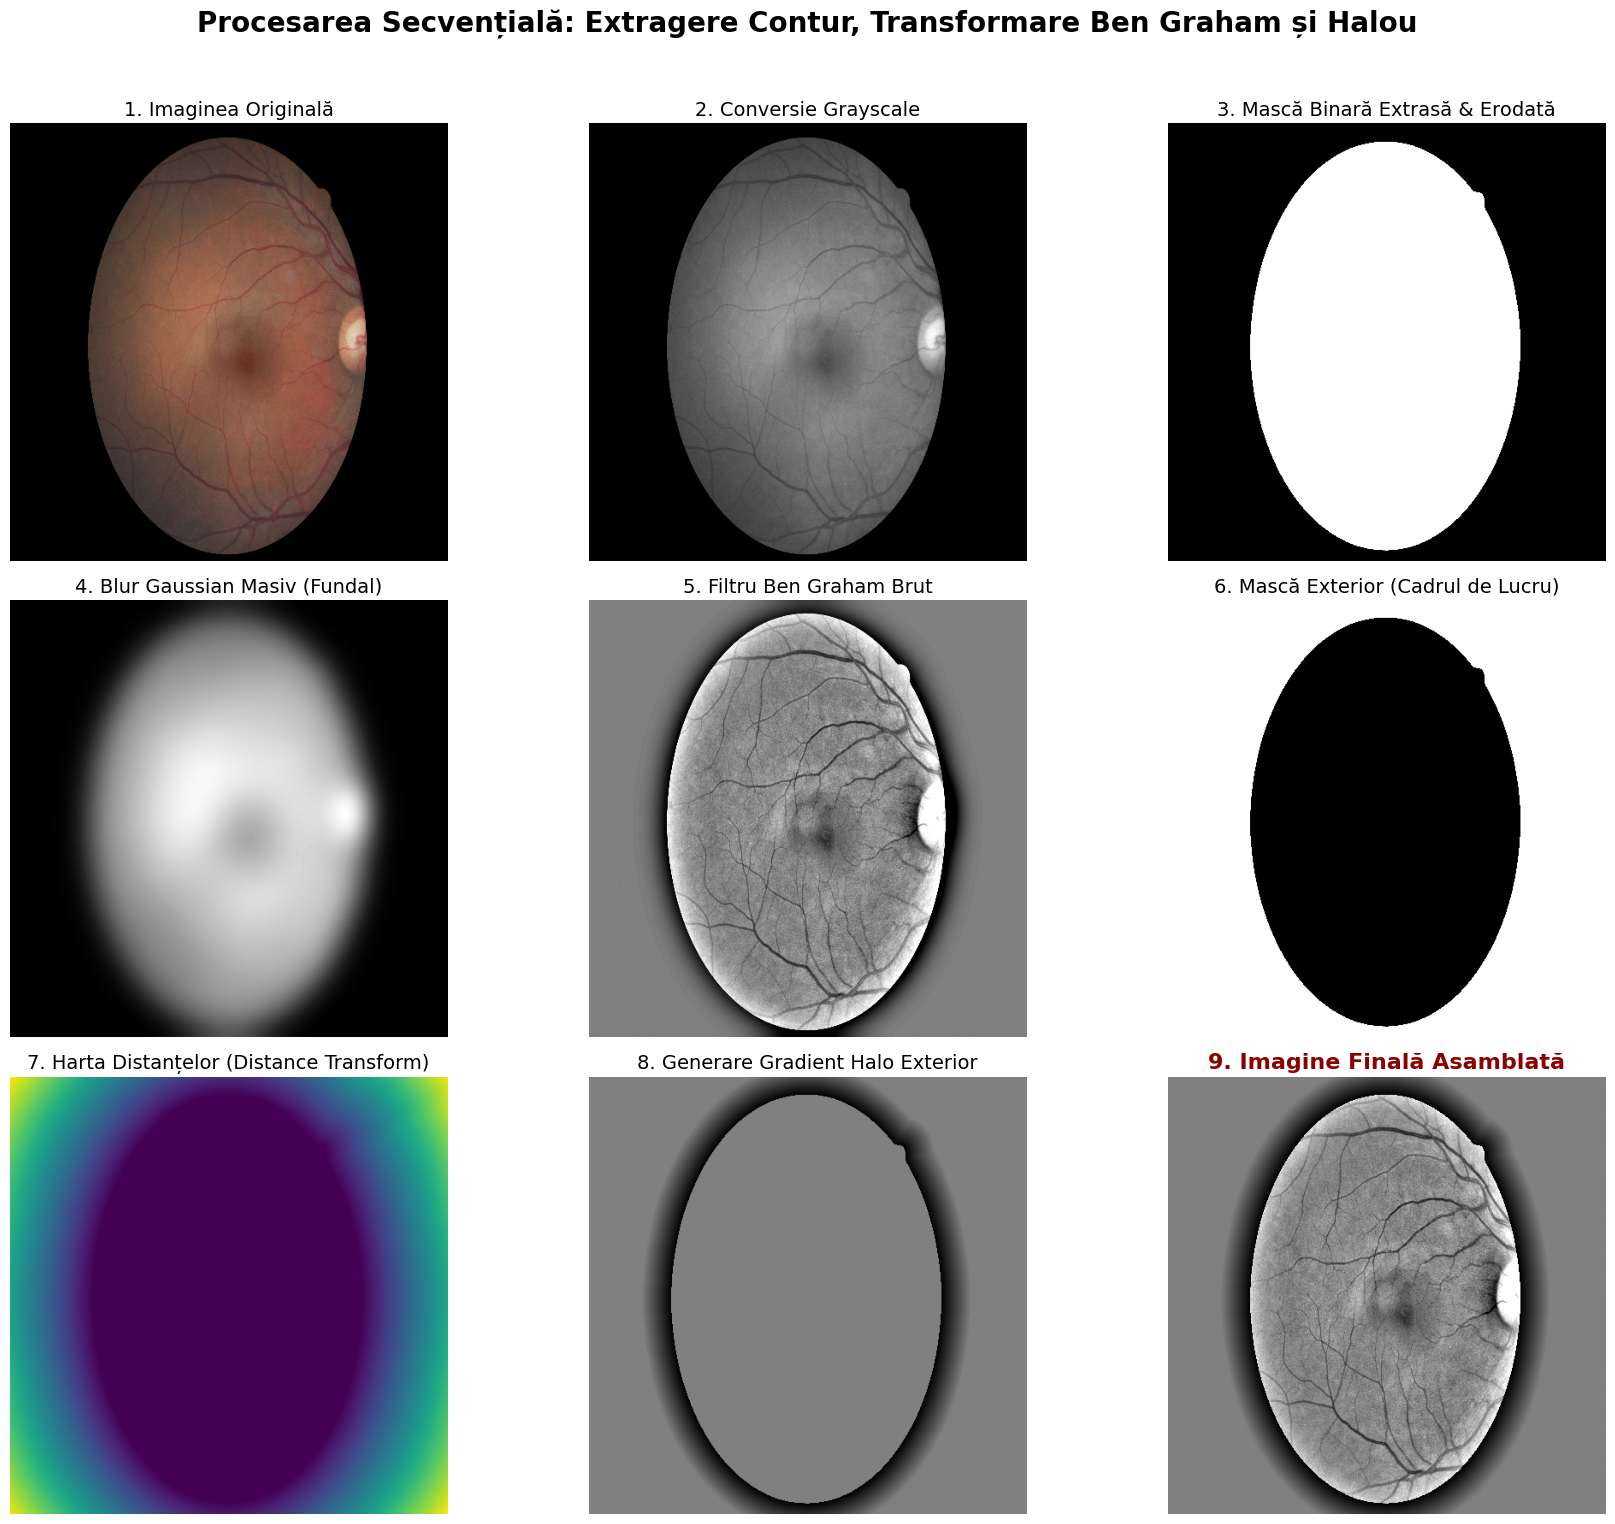

In [3]:
import os
import random

# 1. Setează calea către folderul de unde vrei să tragi imaginile (ex: folderul de train)
folder_imagini = "B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images" 

# 2. Citim toate fișierele din acel folder și le filtrăm doar pe cele de tip imagine
toate_fisierele = os.listdir(folder_imagini)
imagini_disponibile = [f for f in toate_fisierele if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# 3. Verificăm dacă a găsit imagini și alegem una random
if len(imagini_disponibile) > 0:
    imagine_random = random.choice(imagini_disponibile)
    cale_completa = os.path.join(folder_imagini, imagine_random)
    
    print(f"🎲 Am ales la întâmplare imaginea: {imagine_random}")
    
    # 4. Apelăm funcția ta de vizualizare
    img_orig, img_procesata = procesare_ben_graham_detaliata(cale_completa)
else:
    print(f"❌ Nu am găsit nicio imagine cu extensia .jpg/.png în folderul: {folder_imagini}")

In [2]:
import os
from pathlib import Path

def verifica_dataset(cale_dataset):
    base_dir = Path(cale_dataset)
    
    if not base_dir.exists():
        print(f"Eroare: Folderul {base_dir} nu a fost gasit!")
        return

    # Setam split-urile si clasele pe care vrem sa le numaram
    splits = ["test", "train", "val"]
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    # Structura de date pentru a tine evidenta: dictionar in dictionar
    # ex: counts["0"]["train"] = 1800
    counts = {cls: {split: 0 for split in splits} for cls in classes}

    # Culegem datele din foldere
    for split in splits:
        for cls in classes:
            folder_path = base_dir / split / cls
            if folder_path.exists() and folder_path.is_dir():
                # Numaram doar fisierele cu extensii de imagine
                num_images = sum(
                    1 for file in folder_path.iterdir() 
                    if file.is_file() and file.suffix.lower() in extensii_imagini
                )
                counts[cls][split] = num_images

    # Afisam exact in formatul cerut de tine
    print(f"{cale_dataset}")
    for cls in classes:
        print(f"Class {cls}:")
        print(f"\t-> test:  {counts[cls]['test']}")
        print(f"\t-> train: {counts[cls]['train']}")
        print(f"\t-> val:   {counts[cls]['val']}\n")

    print("-" * 40 + "\n")

if __name__ == "__main__":
    # Schimba aici cu calea catre dataset-ul tau
    verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\Diabetic_Balanced_Data")

Eroare: Folderul B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\Diabetic_Balanced_Data nu a fost gasit!


In [145]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train")
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train_cropped")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train
Class 0:
	-> test:  0
	-> train: 25810
	-> val:   0

Class 1:
	-> test:  0
	-> train: 2443
	-> val:   0

Class 2:
	-> test:  0
	-> train: 5292
	-> val:   0

Class 3:
	-> test:  0
	-> train: 873
	-> val:   0

Class 4:
	-> test:  0
	-> train: 708
	-> val:   0

----------------------------------------

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train_cropped
Class 0:
	-> test:  0
	-> train: 25802
	-> val:   0

Class 1:
	-> test:  0
	-> train: 2438
	-> val:   0

Class 2:
	-> test:  0
	-> train: 5288
	-> val:   0

Class 3:
	-> test:  0
	-> train: 872
	-> val:   0

Class 4:
	-> test:  0
	-> train: 708
	-> val:   0

----------------------------------------



In [133]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\my_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\my_dataset
Class 0:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 1:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 2:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 3:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 4:
	-> test:  3864
	-> train: 27054
	-> val:   7728

----------------------------------------



In [144]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_original")
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_augmented")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_original
Class 0:
	-> test:  722
	-> train: 5021
	-> val:   1471

Class 1:
	-> test:  234
	-> train: 1742
	-> val:   467

Class 2:
	-> test:  528
	-> train: 3495
	-> val:   988

Class 3:
	-> test:  56
	-> train: 453
	-> val:   128

Class 4:
	-> test:  66
	-> train: 461
	-> val:   120

----------------------------------------

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_augmented
Class 0:
	-> test:  278
	-> train: 1979
	-> val:   529

Class 1:
	-> test:  737
	-> train: 5050
	-> val:   1473

Class 2:
	-> test:  472
	-> train: 3505
	-> val:   1012

Class 3:
	-> test:  944
	-> train: 6547
	-> val:   1872

Class 4:
	-> test:  934
	-> train: 6539
	-> val:   1880

----------------------------------------



In [191]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset")
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\final_augmented+ben_graham_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset
Class 0:
	-> test:  761
	-> train: 5321
	-> val:   1520

Class 1:
	-> test:  228
	-> train: 1597
	-> val:   456

Class 2:
	-> test:  467
	-> train: 3267
	-> val:   933

Class 3:
	-> test:  75
	-> train: 528
	-> val:   151

Class 4:
	-> test:  54
	-> train: 377
	-> val:   108

----------------------------------------

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\final_augmented+ben_graham_dataset
Class 0:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 1:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 2:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 3:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 4:
	-> test:  1054
	-> train: 7418
	-> val:   2066

----------------------------------------



In [192]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\aptos_new\final_aptos_augmented+ben_graham_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\aptos_new\final_aptos_augmented+ben_graham_dataset
Class 0:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 1:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 2:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 3:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 4:
	-> test:  190
	-> train: 1330
	-> val:   379

----------------------------------------



In [3]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs_clean\step1_split_standard")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs_clean\step1_split_standard
Class 0:
	-> test:  6534
	-> train: 45738
	-> val:   13069

Class 1:
	-> test:  621
	-> train: 4343
	-> val:   1241

Class 2:
	-> test:  1315
	-> train: 9206
	-> val:   2631

Class 3:
	-> test:  209
	-> train: 1461
	-> val:   417

Class 4:
	-> test:  191
	-> train: 1340
	-> val:   383

----------------------------------------



In [140]:
# Show number of images from cleaned_dataset (only 0/1/2/3/4 structure)
from matplotlib.pylab import split


def verifica_dataset_2(cale_dataset):
    base_dir = Path(cale_dataset)
    
    if not base_dir.exists():
        print(f"Eroare: Folderul {base_dir} nu a fost gasit!")
        return

    # Setam split-urile si clasele pe care vrem sa le numaram
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    # Structura de date pentru a tine evidenta: dictionar in dictionar
    # ex: counts["0"] = 1800
    counts = {cls: 0 for cls in classes}

    # Culegem datele din foldere
    for cls in classes:
        folder_path = base_dir / cls
        if folder_path.exists() and folder_path.is_dir():
            # Numaram doar fisierele cu extensii de imagine
            num_images = sum(
                1 for file in folder_path.iterdir() 
                if file.is_file() and file.suffix.lower() in extensii_imagini
            )
            counts[cls] = num_images

    # Afisam exact in formatul cerut de tine
    print(f"{cale_dataset}")
    for cls in classes:
        print(f"Class {cls}:")
        print(f"\t-> train: {counts[cls]}")

    print("-" * 40 + "\n")

if __name__ == "__main__":
    # Schimba aici cu calea catre dataset-ul tau
    verifica_dataset_2(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\cleaned_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\cleaned_dataset
Class 0:
	-> train: 11469
Class 1:
	-> train: 1198
Class 2:
	-> train: 1979
Class 3:
	-> train: 327
Class 4:
	-> train: 221
----------------------------------------



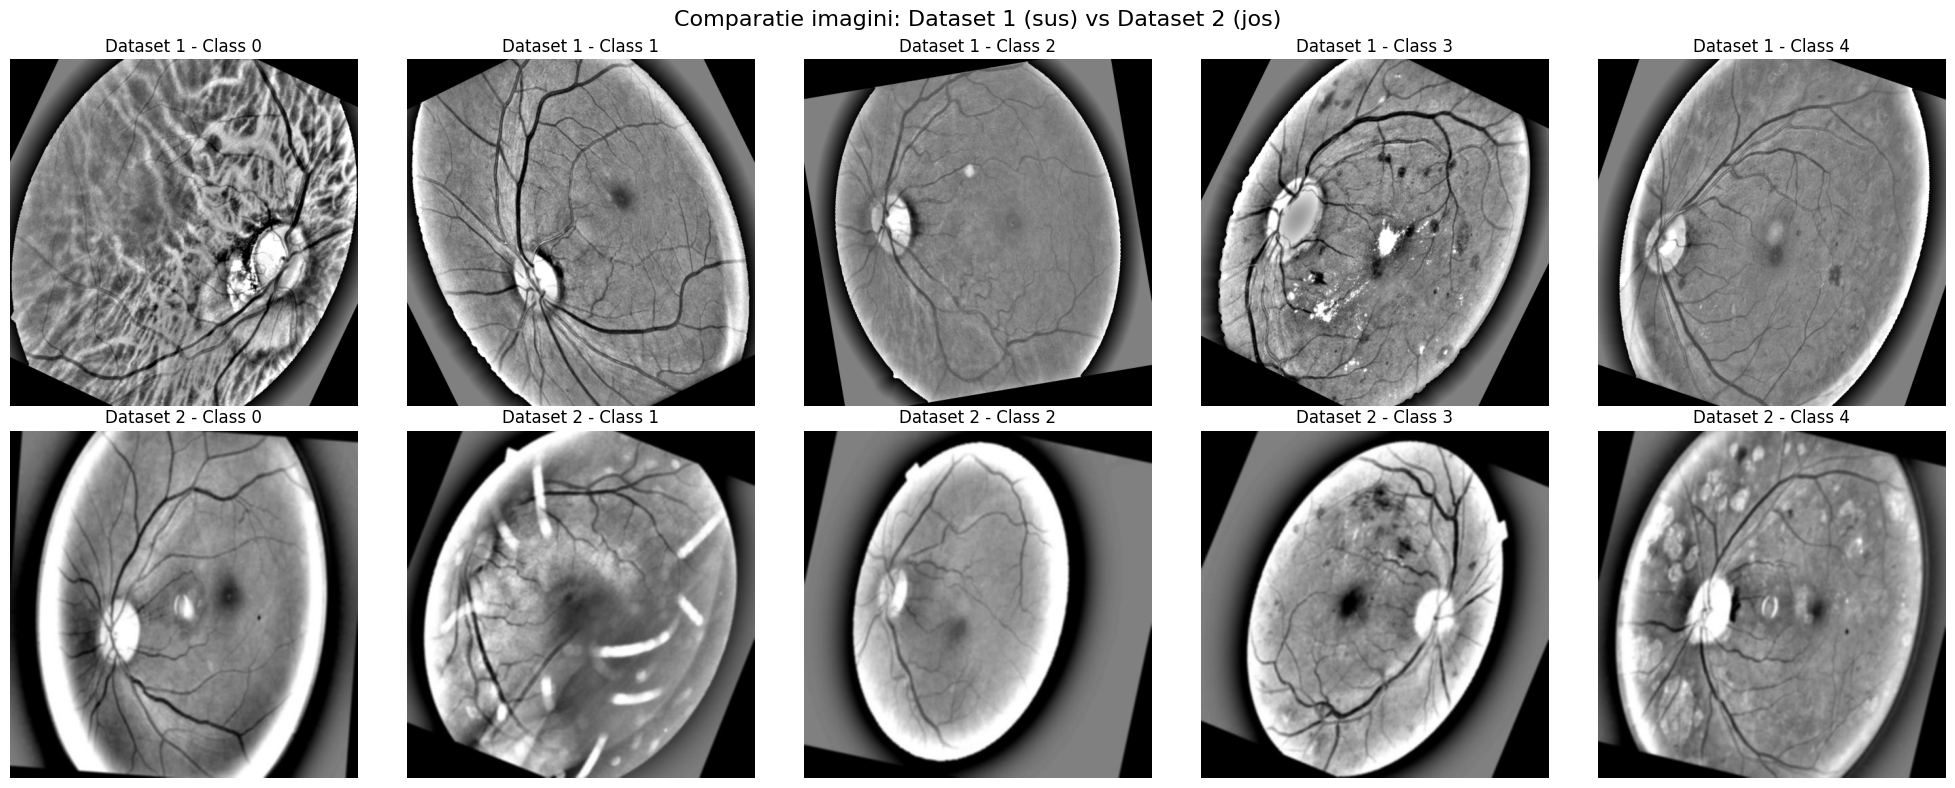

In [7]:
# Show 5 images (1 from each class) for 2 different datasets: 2 subplots with 1 line and 5 columns, each column is a class (0/1/2/3/4) and each line is a dataset (ex: original vs augmented)
def arata_imagini_random_diferite_dataseturi(cale_dataset_1, cale_dataset_2):
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle("Comparatie imagini: Dataset 1 (sus) vs Dataset 2 (jos)", fontsize=16)

    for col, cls in enumerate(classes):
        # Dataset 1
        folder_1 = Path(cale_dataset_1) / cls
        imagini_1 = [f for f in folder_1.iterdir() if f.is_file() and f.suffix.lower() in extensii_imagini]
        if imagini_1:
            img_1 = cv2.imread(str(np.random.choice(imagini_1)))
            img_1_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
            axes[0, col].imshow(img_1_rgb)
            axes[0, col].set_title(f"Dataset 1 - Class {cls}")
            axes[0, col].axis('off')
        else:
            axes[0, col].set_title(f"Dataset 1 - Class {cls}\n(No images)")
            axes[0, col].axis('off')

        # Dataset 2
        folder_2 = Path(cale_dataset_2) / cls
        imagini_2 = [f for f in folder_2.iterdir() if f.is_file() and f.suffix.lower() in extensii_imagini]
        if imagini_2:
            img_2 = cv2.imread(str(np.random.choice(imagini_2)))
            img_2_rgb = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)
            axes[1, col].imshow(img_2_rgb)
            axes[1, col].set_title(f"Dataset 2 - Class {cls}")
            axes[1, col].axis('off')
        else:
            axes[1, col].set_title(f"Dataset 2 - Class {cls}\n(No images)")
            axes[1, col].axis('off')

    plt.tight_layout()
    plt.show()
    
if __name__ == "__main__":
    arata_imagini_random_diferite_dataseturi(
        r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\final_balanced_augmented+ben_graham_dataset\train",
        r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\Diabetic_Balanced_Data\train"
    )

## Antrenare

In [4]:
# Split all images from datasets/originals/EyePACS/Images in folders containing max 10000 images
from pathlib import Path
import shutil

def split_images_in_batches(input_folder, output_folder, batch_size=10000):
    input_folder = Path(input_folder)
    output_folder = Path(output_folder)
    
    if not input_folder.exists():
        print(f"Eroare: Folderul {input_folder} nu exista.")
        return
    
    output_folder.mkdir(parents=True, exist_ok=True)
    
    # Colectam toate imaginile
    imagini = sorted([p for p in input_folder.iterdir() if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}])
    
    # Impartim in batch-uri
    for i in range(0, len(imagini), batch_size):
        batch = imagini[i:i + batch_size]
        batch_num = (i // batch_size) + 1
        batch_folder = output_folder / f"batch_{batch_num}"
        batch_folder.mkdir(parents=True, exist_ok=True)
        
        for img_path in batch:
            shutil.copy2(img_path, batch_folder / img_path.name)
        
        print(f"Batch {batch_num}: {len(batch)} imagini copiate in {batch_folder}")

if __name__ == "__main__":
    split_images_in_batches(
        r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images",
        r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split"
    )

Batch 1: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_1
Batch 2: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_2
Batch 3: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_3
Batch 4: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_4
Batch 5: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_5
Batch 6: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_6
Batch 7: 10000 imagini copiate in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\Images_split\batch_7
Batch 8: 10000 imagini copiate in B:\Proj